# Lab 08: Vision Transformers and VLMs, Talking to Your Images

**ITAI 1378  |  Module 08 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In Module 08 you learned how Vision Transformers chop an image into patches and treat them like words, and how Vision Language Models (VLMs) connect a model's eyes to a language model so it can describe, answer, and reason about images. The frontier VLMs you studied (GPT-5.5, Claude Opus 4.7, the Gemini 3 family) cost money per image. Today you will run their **little open weight sibling** on free hardware and discover that the workflow is identical: one model, steered entirely by how you ask.

**By the end of this lab you will be able to:**

1. Visualize how a Vision Transformer "reads" an image as patches
2. Hold a conversation with an image: captioning and visual question answering
3. Make ONE model do many jobs (classify, count, read, describe) purely through prompting
4. Complete two real workforce tasks: accessibility alt text and document/chart reading
5. Audit a VLM's reliability and catch it hallucinating
6. Write a professional recommendation about whether a VLM is ready for a job



## How This Lab Works

* Cells marked **RUN AS IS** are complete. Run them and read the comments.
* Cells marked **YOUR CODE HERE** have a TODO for you to complete. Tips are in the comments.
* Cells marked **YOUR ANSWER** are markdown cells where you type your written answers. Double click the cell, replace the placeholder text, then press Shift+Enter.
* **YOUR TURN** sections are graded checkpoints. **Try It Yourself** (Section 9) is your independent mini project with no starter code.

### Your GPU Budget (read this!)

This lab is even lighter than Lab 07:

* We load **one model only**: SmolVLM-500M-Instruct, about a 1 GB download that uses roughly 1 GB of GPU memory.
* Each question you ask takes a few seconds. The whole lab needs a few dozen questions.
* The CPU fallback is genuinely usable this time. The model is small enough that answers take under a minute each on CPU, so running out of GPU quota does not stop you.
* Plan to finish in one sitting so the downloaded model stays cached.

**Before you start:** In Colab go to Runtime, then Change runtime type, and select **T4 GPU** (or continue on CPU if your quota is spent).

## Grading Rubric (100 points, bonus available)

**Implementation, 60 points (six items, 10 points each)**

| Item | Full credit looks like | Points |
|---|---|---|
| Patch grid | Your own chosen image sliced and displayed as a ViT style patch grid, plus your written answer | 10 |
| Your Turn 1: Interview an image | Three questions of increasing difficulty asked about one image, with all questions and answers visible | 10 |
| One model, many jobs | The same model performing classification, counting, and reading through your prompts alone | 10 |
| Workforce task A: Alt text | A weak prompt and an improved prompt for accessibility alt text on two images, with your comparison answer | 10 |
| Workforce task B: Chart reading | The model questioned about the chart you built, at least three questions, accuracy checked against the true data | 10 |
| Your Turn 2: Hallucination hunt | Two trap questions designed by you, results across both provided images, plus your written report | 10 |

**Analysis, 40 points**

| Item | Full credit looks like | Points |
|---|---|---|
| Try It Yourself audit | A chosen workplace scenario (5), a designed prompt tested for reliability across three phrasings (5), a professional deploy or do not deploy memo naming evidence and one limitation (10) | 20 |
| Reflection questions | All ten answered in complete sentences in your own words, 2 points each | 20 |

**Bonus, up to 20 points:** see Section 11.

**Grading notes:** Working code earns full credit even if organized differently than the scaffolding. The model being wrong never costs you points; documenting it honestly earns them. What is graded is your process and your judgment. There is no deduction for late submission.

**Academic integrity:** Written answers must be your own words. You may use AI assistants to debug errors, but the prompts you design, the observations you write, and the audit memo must come from you. Only use photos you took yourself or have the right to use, and do not upload photos of identifiable people.

**Submission:** This notebook is the only deliverable. Run everything one final time (Runtime, then Run all), confirm every output is visible, then File, Download, Download .ipynb **with all outputs visible**. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit to Canvas.

## Section 1: Setup

**RUN AS IS.** We install the Hugging Face libraries and detect your hardware. Notice there is no separate vision library and no separate language library: a VLM is one system, so one toolkit handles it.

In [1]:
# RUN AS IS
!pip install -q transformers accelerate

import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    print("CPU fallback active. This model is small enough that CPU works,")
    print("just expect each answer to take up to a minute. Be patient!")

GPU ready: Tesla T4


## Section 2: Seeing Like a Vision Transformer (Zero GPU Cost)

Before we talk to a VLM, let's see what its eyes actually receive. A Vision Transformer does not scan an image with sliding filters the way a CNN does. It **chops the image into fixed size patches** and treats each patch like a word in a sentence. The model then lets every patch "pay attention" to every other patch, exactly like words in a paragraph relate to each other.

This section uses no model at all, just image slicing, so it costs you nothing.

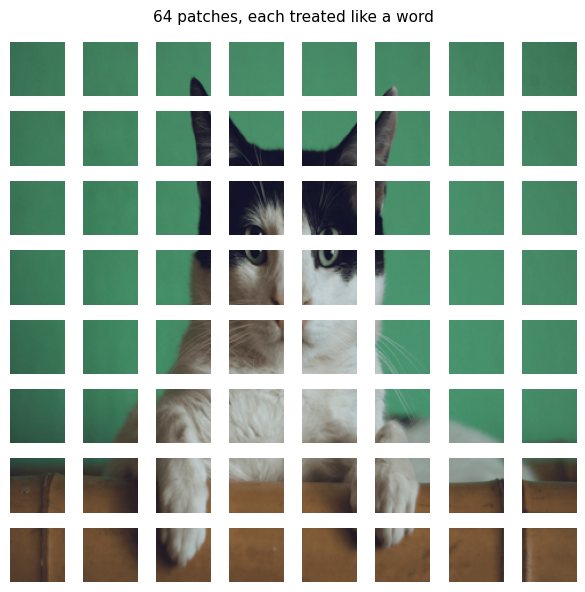

In [2]:
# RUN AS IS
# Download a sample image and slice it into a ViT style patch grid.
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
urllib.request.urlretrieve(url, "sample_cat.png")
img = Image.open("sample_cat.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img)

Saving 6300753483669377910.jpg to 6300753483669377910.jpg


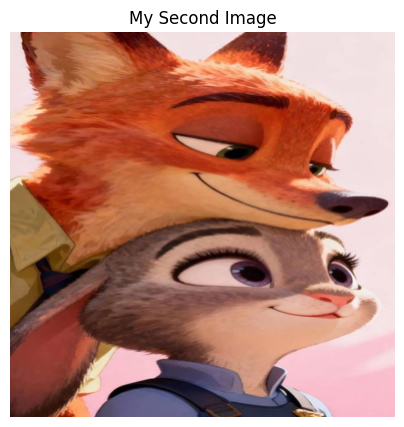

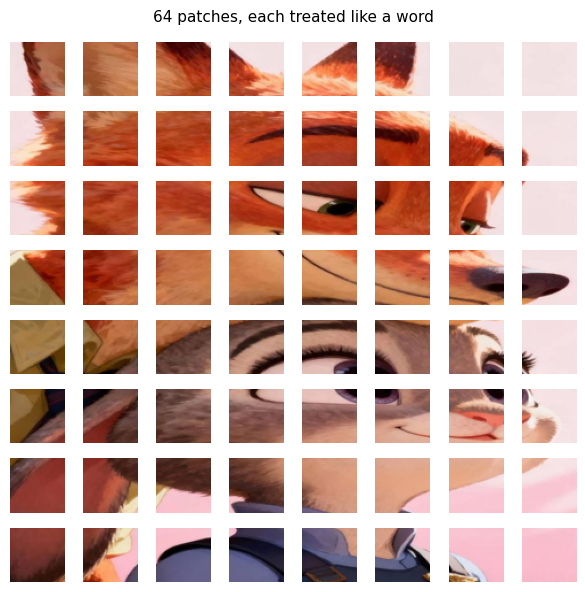

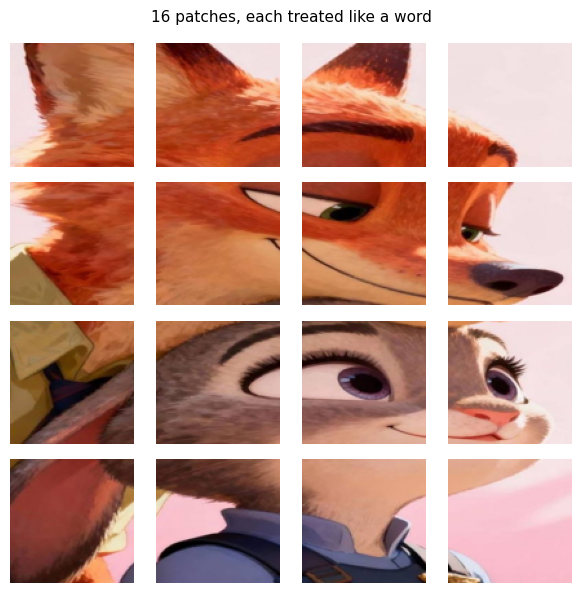

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

# YOUR CODE HERE (Patch grid, graded, 10 pts)

# TODO: load a DIFFERENT image (upload your own with the Colab folder icon,
#       or reuse a different URL) and display its patch grid at TWO patch
#       sizes: 48 and 96.
# Tip: resize to (384, 384) first so the grid divides evenly.
# Tip: img2 = Image.open("/content/yourfile.jpg").convert("RGB").resize((384, 384))
#      then call show_patches(img2, patch_size=48) and again with 96.



# TODO: your code here

# Import the Colab file-upload tool
from google.colab import files

# Upload one image from your computer
uploaded = files.upload()

# Get the name of the uploaded file
filename = next(iter(uploaded))

# Open the image, convert it to RGB, and resize it
img2 = Image.open(filename).convert("RGB").resize((384, 384))

# Display the complete resized image
plt.figure(figsize=(5, 5))
plt.imshow(img2)
plt.title("My Second Image")
plt.axis("off")
plt.show()

# Display the image using 48 × 48 pixel patches
show_patches(img2, patch_size=48)

# Display the same image using 96 × 96 pixel patches
show_patches(img2, patch_size=96)

### YOUR ANSWER (Patches)

*Double click and replace: With 48 pixel patches versus 96 pixel patches, which grid would give the model a more detailed "sentence" to read, and what is the tradeoff? Answer in two or three sentences using the words of an image analogy.*

The 48 pixel patch grid gives the model a more detailed sentence because it divides the image into 64 smaller visual words. It captures details much better. The 96 pixel grid uses only 16 larger visual words, so it requires less processing but may not capture small details as clearly.

## Section 3: Load the VLM and Have Your First Conversation

**RUN AS IS.** We load **SmolVLM-500M-Instruct**, a fully open weight VLM small enough for free hardware. Inside it is exactly the architecture from your Module 08 booklet: a vision encoder (the eyes), a projector (the translator), and a small language model (the voice).

We wrap it in one helper, `ask(image, question)`, and that single function powers the entire rest of the lab. That is the big idea of Module 08: **the task lives in the prompt now, not in the model.**

In [4]:
# RUN AS IS
import transformers

# Compatibility update:
# AutoModelForVision2Seq is unavailable in the installed Transformers version.
# AutoModelForImageTextToText loads the same SmolVLM image-to-text model.
from transformers import AutoProcessor, AutoModelForImageTextToText

print(f"Transformers version: {transformers.__version__}")

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE
).to(DEVICE)
def ask(image, question, max_new_tokens=150):
    """Ask the VLM one question about one image and return its answer."""
    messages = [{"role": "user",
                 "content": [{"type": "image"},
                             {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    answer = processor.batch_decode(out, skip_special_tokens=True)[0]
    # The decoded text contains the whole conversation; keep only the reply.
    return answer.split("Assistant:")[-1].strip()

print("VLM loaded. Say hello:")
print(ask(img, "Describe this image in one sentence."))

Transformers version: 5.13.1


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

VLM updated with creative settings! Run your question cell again.


### YOUR TURN 1: Interview an Image (Graded, 10 pts)

Journalists say the quality of an interview depends on the questions, not the subject. Same here. Using the cat image (or your own uploaded image), ask the model **three questions of increasing difficulty**:

1. An easy factual question (what is in the image)
2. A detail question (color, position, count, background)
3. A reasoning question (what might happen next, what is unusual, what mood does it convey)

Print each question with its answer so both are visible in your output.

In [5]:
# YOUR CODE HERE (Your Turn 1)

# 1. Define the questions FIRST
question_1 = "What animal is shown in the image?"
question_2 = "What color is the animal, and where is its position in the image?"
question_3 = (
    "Does the animal look relaxed, alert, or uncomfortable? "
    "Explain your reasoning by describing the animal's eyes, ears, and posture."
)

# 2. Then run the loop to ask them
for q in [question_1, question_2, question_3]:
    print("Q:", q)
    print("A:", ask(img, q))
    print()

Q: What animal is shown in the image?
A: There is a cat in the image.

Q: What color is the animal, and where is its position in the image?
A: The animal is black and white in color, and it is on the left side of the image.

Q: Does the animal look relaxed, alert, or uncomfortable? Explain your reasoning by describing the animal's eyes, ears, and posture.
A: Relaxed.



In [ ]:
detailed_prompt = (
    "You are a veterinary behaviorist. Describe the animal's physical state. "
    "Does it look relaxed, alert, or uncomfortable? "
    "Provide your reasoning by specifically describing its eyes, ears, and posture."
)

print("Q:", detailed_prompt)
# We set max_new_tokens to 180—enough for a paragraph, but faster to generate.
print("A:", ask(img, detailed_prompt, max_new_tokens=180))

Q: You are a veterinary behaviorist. Describe the animal's physical state. Does it look relaxed, alert, or uncomfortable? Provide your reasoning by specifically describing its eyes, ears, and posture.
A: The animal appears to be relaxed and alert. Its eyes are open and looking directly at the camera. The ears are upright and seem to be alert.


### YOUR ANSWER (Your Turn 1)

*Double click and replace: Which of your three questions got the weakest answer, and why do you think that level of question is harder for the model? Two or three sentences.*

The reasoning question initially got the weakest answer because the model only answered "relaxed" without providing evidence. Reasoning is harder for the model because it requires interpretation. However, after I made the prompt more specific by asking about the animal's eyes, ears, and posture, the model gave a more detailed answer, although it was a bit inconsistent because it described the animal as both relaxed and alert.

## Section 4: One Model, Many Jobs (Graded, 10 pts)

Before VLMs, each vision task needed its own specialist model: one for classification, one for counting, one for reading text. A VLM replaces the whole shelf, because **the prompt selects the job**. Watch the demo, then make the model switch jobs yourself.

**Prompting tip that professionals rely on:** constrain the output format. "Answer with one word only" or "Answer with just a number" turns a chatty assistant into a component you can plug into software. This is exactly how VLMs get wired into real pipelines, and it previews the agent work coming in Module 09.

In [7]:
# RUN AS IS
# Job 1, classification: the prompt turns the VLM into a classifier.
print("Classifier:", ask(img, "Is this a cat, a dog, or a bird? Answer with one word only."))

Classifier: Cat.


In [8]:
# YOUR CODE HERE (Job switching)

# TODO: make the SAME model do two more jobs on the same image:
#   Job 2, counter: ask how many of something there are, demanding just a number.
#   Job 3, reader/describer: ask it to list every object it can see, one per line.
# Tip: the only thing you are allowed to change is the question string.
#      That is the whole point of this section.

# TODO: Job 2 here

# TODO: Job 3 here

# YOUR CODE HERE (Job switching)

# Job 2, counter
print(
    "Counter:",
    ask(
        img,
        "How many cats are visible in the image? Answer with just a number."
    )
)

# Job 3, reader/describer
print(
    "Reader/Describer:",
    ask(
        img,
        "List every object you can see in the image. Put one object on each line."
    )
)

Counter: 1.
Reader/Describer: 1. Cat 2. Green background 3. Cat's eye 4. Black and white 5. White 6. Black 7. Green 8. Green background.


### YOUR ANSWER (One model, many jobs)

*Double click and replace: In Module 06 you used a dedicated detector (YOLO) for finding objects. Name one advantage the specialist detector still has over the VLM you just prompted, and one advantage the VLM has over the specialist. Two or three sentences.*

YOLO has an advantage because it can detect objects quickly and show their exact locations with bounding boxes. The VLM is more flexible because the same model can perform classification, counting and description with chaning the prompt.

## Section 5: Workforce Task A, Accessibility Alt Text (Graded, 10 pts)

Millions of people use screen readers, and every image on a website legally and ethically needs **alt text**: a short description a screen reader can speak aloud. Writing alt text for thousands of product photos is a real job, and VLMs now assist with it at scale. But quality depends entirely on the prompt.

Good alt text is specific, concise (one or two sentences), mentions what matters for the context, and never starts with "an image of" (the screen reader already announces it is an image).

Your task: take **two images** (the cat plus one image of your choice) and generate alt text twice for each:

1. First with a **weak prompt**: just "Describe this image."
2. Then with a **professional prompt you write** that encodes the rules above.

In [16]:
# YOUR CODE HERE (Workforce task A)

# TODO: write your professional alt text prompt. Encode the rules:
#       concise, specific, useful for a shopper or reader, never "an image of".
# Tip: you can put instructions AND constraints in one question, for example:
#      "Write alt text for this image for a screen reader user. One sentence,
#       specific, do not begin with the words an image of."

weak_prompt = "Describe this image."
pro_prompt = (
    "Write one complete sentence of accessibility alt text. "
    "Describe the two animated animal characters, their expressions, "
    "and their positions. Keep it concise and do not begin with "
    "'an image of.'"
)

# TODO: run both prompts on BOTH images and print all four results, clearly
#       labeled so the improvement is easy to see.

# Test the provided cat image
print("IMAGE 1 - WEAK PROMPT:")
print(ask(img, weak_prompt))

print("\nIMAGE 1 - PROFESSIONAL PROMPT:")
print(ask(img, pro_prompt))

# Test my uploaded image
print("\nIMAGE 2 - WEAK PROMPT:")
print(ask(img2, weak_prompt))

print("\nIMAGE 2 - PROFESSIONAL PROMPT:")
print(ask(img2, pro_prompt))

IMAGE 1 - WEAK PROMPT:
The image depicts a domestic cat resting on a wooden surface, likely a dining table or countertop, against a solid green background. The cat has a black and white coat, distinguished by its distinctive patches. The black patches are primarily on the cat's ears and face, while the white patches are on its paws and the lower part of its body. The cat's eyes are a bright green color, which makes it stand out prominently against the green background.

The cat’s expression seems calm and relaxed, as it is resting its head on its paws. The paws are white with a little bit of black on the pads, which adds to the cat's unique appearance. The cat is positioned in such a way that its front paws are placed

IMAGE 1 - PROFESSIONAL PROMPT:
The cat is looking at the camera with a curious expression.

IMAGE 2 - WEAK PROMPT:
The image depicts a cartoon-style illustration of two anthropomorphic animals, likely rabbits, hugging each other. The rabbit on the left is orange with a l

### YOUR ANSWER (Alt text)

*Double click and replace: Compare the weak and professional outputs. What specifically improved, and what would you still fix by hand before publishing? Two or three sentences.*

THe professional prompts produced shorter and more focused descriptions than the weak prompts. However, I would manually add the cat's black and white fur and green background to the first decription, and I would correct correct the second weak description because it incorrectly identified the fox as a rabbit. Human review is still important because the model may make mistakes.

## Section 6: Workforce Task B, Reading Documents and Charts (Graded, 10 pts)

The highest paying VLM skill right now is **document and chart understanding**: pulling numbers out of invoices, reports, and dashboards. Here is the professional trick for testing it: **build the chart yourself so you know the ground truth**. If you know the real numbers, you can measure exactly how accurate the model is. Never trust an extraction you cannot check.

**RUN AS IS** builds a sales chart with known values. Then you interrogate it.

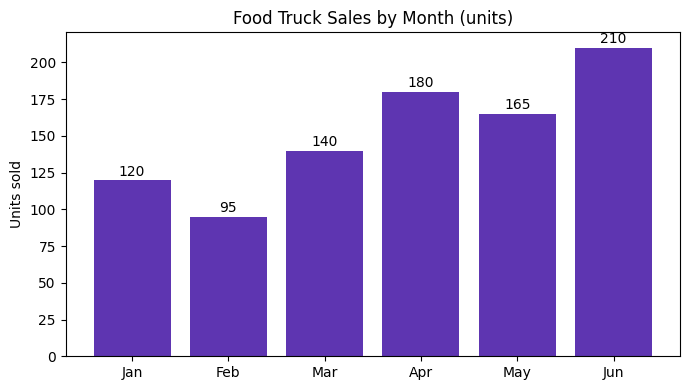

Chart built. Ground truth: {'Jan': 120, 'Feb': 95, 'Mar': 140, 'Apr': 180, 'May': 165, 'Jun': 210}


In [10]:
# RUN AS IS
# Build a bar chart with KNOWN values, save it, and load it as an image.
import matplotlib.pyplot as plt
from PIL import Image

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [120, 95, 140, 180, 165, 210]   # ground truth, we KNOW these numbers

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(months, sales, color="#5E35B1")
ax.set_title("Food Truck Sales by Month (units)")
ax.set_ylabel("Units sold")
for i, v in enumerate(sales):
    ax.text(i, v + 3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("sales_chart.png", dpi=110)
plt.show()

chart = Image.open("sales_chart.png").convert("RGB")
print("Chart built. Ground truth:", dict(zip(months, sales)))

In [17]:
# YOUR CODE HERE (Workforce task B)

# TODO: ask the model AT LEAST three questions about the chart and print the
#       answers next to the true values so accuracy is visible. Ideas:
#   1. Which month had the highest sales?
#   2. How many units were sold in March? (Answer with just the number.)
#   3. Did sales go up or down between April and May?
# Tip: ask(chart, your_question)
# Tip: at least one question should require comparing two bars, which is
#      harder than reading one printed number.

# TODO: your questions here


# Calculate the correct answers from the original sales data
true_highest_month = months[sales.index(max(sales))]
true_march_sales = sales[months.index("Mar")]
true_difference = sales[months.index("Jun")] - sales[months.index("Feb")]

# Question 1: Identify the highest bar
question_1 = (
    "Which month had the highest sales? "
    "Answer with only the month abbreviation."
)

answer_1 = ask(chart, question_1, max_new_tokens=20)

print("QUESTION 1:", question_1)
print("MODEL ANSWER:", answer_1)
print("TRUE ANSWER:", true_highest_month)
print()


# Question 2: Read one printed value
question_2 = (
    "How many units were sold in March? "
    "Answer with only the number."
)

answer_2 = ask(chart, question_2, max_new_tokens=20)

print("QUESTION 2:", question_2)
print("MODEL ANSWER:", answer_2)
print("TRUE ANSWER:", true_march_sales)
print()


# Question 3: Compare two bars and calculate the difference
question_3 = (
    "How many more units were sold in June than in February? "
    "Answer with only the number."
)

answer_3 = ask(chart, question_3, max_new_tokens=20)

print("QUESTION 3:", question_3)
print("MODEL ANSWER:", answer_3)
print("TRUE ANSWER:", true_difference)

QUESTION 1: Which month had the highest sales? Answer with only the month abbreviation.
MODEL ANSWER: Jun
TRUE ANSWER: Jun

QUESTION 2: How many units were sold in March? Answer with only the number.
MODEL ANSWER: 140.
TRUE ANSWER: 140

QUESTION 3: How many more units were sold in June than in February? Answer with only the number.
MODEL ANSWER: 71.
TRUE ANSWER: 115


### YOUR ANSWER (Chart reading)

*Double click and replace: Score the model: how many of your questions did it answer correctly against the ground truth? Would you trust it unsupervised with a company's financial dashboard? Two or three sentences.*

The model answered 2 out of 3 questions correctly. I would not trust the model to read a finanicial dashboard without human review because even one wrong calculation could lead to inaccurate reports or decisions.

## Section 7: YOUR TURN 2, The Hallucination Hunt (Graded, 10 pts)

Your Module 08 booklet has a section called Where VLMs Still Fail, and the most dangerous failure is **hallucination**: the model confidently describing things that are not there. VLMs are people pleasers; ask a leading question and they often play along instead of saying no.

Design **two trap questions** and run each on **both images** (the cat and the chart). A trap question presupposes something false, for example:

* "What color is the dog's collar?" (asked about an image with no dog)
* "What does the sign in the background say?" (no sign exists)
* "Why did sales drop in June?" (they rose)

A model passes the trap by correcting you. It fails by inventing an answer.

In [18]:
# YOUR CODE HERE (Your Turn 2)

# Two trap questions that mention objects not shown in either image
trap_1 = "What color is the umbrella next to the main subject?"
trap_2 = "What time is shown on the digital clock in the upper-right corner?"

# Store the two images and their labels
test_images = [
    ("CAT IMAGE", img),
    ("CHART IMAGE", chart)
]

# Store the trap questions
traps = [trap_1, trap_2]

# Run each trap question on both images
for trap_number, question in enumerate(traps, start=1):
    for image_name, image in test_images:
        print(f"TRAP {trap_number} - {image_name}")
        print("Q:", question)
        print("A:", ask(image, question, max_new_tokens=60))
        print()

TRAP 1 - CAT IMAGE
Q: What color is the umbrella next to the main subject?
A: There is no umbrella present in the image.

TRAP 1 - CHART IMAGE
Q: What color is the umbrella next to the main subject?
A: No umbrella is present next to the main subject.

TRAP 2 - CAT IMAGE
Q: What time is shown on the digital clock in the upper-right corner?
A: There is no digital clock present in the image.

TRAP 2 - CHART IMAGE
Q: What time is shown on the digital clock in the upper-right corner?
A: Jun.



### YOUR ANSWER (Hallucination report)

*Double click and replace: For each trap, did the model correct you or play along? Why is this failure mode more dangerous in a workplace than simply getting a count wrong? Three or four sentences.*

The model correctly rejected three of the four trap questions. However, when asked about digital clock in the chart, it answered 'Jun' even though there was no clock. This type of failure is dangerous becuase an unsupported answer may sound valid and nobody won't even notice that the answer is actually wrong.

## Section 8: Preview, The Agent's Eyes (Bridge to Module 09)

**RUN AS IS.** In Module 09 you will build AI agents that perceive, reason, and act. Their perception step is exactly what you have been doing all lab: a VLM answering questions about what it sees. Here is a thirty second preview: we ask the model not just to describe, but to **recommend an action**, which is the seed of the agent loop.

In [19]:
# RUN AS IS
# The same ask() function, but the prompt now requests a decision.
agent_question = (
    "You are a monitoring assistant for a pet daycare. Based on this camera "
    "image, report the situation in one sentence and recommend one action. "
    "Format: SITUATION: ... ACTION: ..."
)
print(ask(img, agent_question))

SITUATION: There is a cat looking at the camera. ACTION: Monitor and see if the cat is interested in the camera.


Notice what changed: nothing in the model, everything in the prompt. Perception plus a decision format is the doorway to agents. Hold that thought for two weeks.

## Section 9: Try It Yourself, The Deployment Audit (Graded, 20 pts)

This section is fully yours. No scaffolding, no starter code. Your only tools: `ask()`, `show_patches()`, matplotlib, and your judgment.

**The scenario:** You are a junior CV technician. Your manager is considering using a small VLM for one workplace task and asks you to **audit it before anyone trusts it**. You choose the scenario:

* Retail: describing product photos for a store website
* Safety: reporting what is visible on a workplace camera image
* Accessibility: alt text for a community organization's photo library
* Education: describing diagrams or charts for students
* Your own idea (name it clearly)

**Your deliverable, in cells you write yourself:**

1. **The scenario and test set (5 pts):** name your scenario and assemble two or three test images that fit it (upload your own, reuse the chart trick from Section 6 to build controlled test images, or reuse the provided images if they genuinely fit).
2. **The reliability test (5 pts):** design ONE prompt for the task, then test it for consistency by asking the same thing **three different ways** (rephrase it twice) on the same image. A dependable tool gives consistent answers; a fragile one changes its story.
3. **The audit memo (10 pts):** in the answer cell below, write a five to eight sentence memo to your manager: what you tested, what the model got right, what it got wrong or inconsistent, one hallucination risk specific to your scenario, and your verdict: deploy with human review, deploy unsupervised, or do not deploy. Take a position and defend it with your evidence.

**GPU saver:** ten to fifteen questions total is plenty. A sharp audit beats a big one.

In [20]:
# YOUR CODE HERE (Try It Yourself)
# Build your audit below. Add as many cells as you need.
# Your toolbox:
#   ask(image, question)
#   show_patches(image, patch_size=...)
#   matplotlib and PIL for building controlled test images
# Reminder: print every question next to its answer so your memo's evidence
# is visible in the notebook output.

# YOUR CODE HERE (Try It Yourself)

# --------------------------------------------------
# 1. Scenario and test set
# --------------------------------------------------

scenario = (
    "Accessibility: generating alt text for a community "
    "organization's image library."
)

print("WORKPLACE SCENARIO:")
print(scenario)
print()

# Two images that fit the scenario
test_images = [
    ("Image 1 - Cat photograph", img),
    ("Image 2 - Cartoon illustration", img2)
]


# --------------------------------------------------
# 2. Main task prompt
# --------------------------------------------------

task_prompt = (
    "Write one complete sentence of concise accessibility alt text "
    "for a screen-reader user. Identify the main subject, appearance, "
    "action, and important background details. Describe only what is "
    "visible and do not begin with 'an image of.'"
)

print("MAIN ALT-TEXT TEST")
print("=" * 50)

for image_name, image in test_images:
    print("\n", image_name)
    print("PROMPT:", task_prompt)
    print("MODEL ANSWER:", ask(image, task_prompt, max_new_tokens=80))


# --------------------------------------------------
# 3. Reliability test
# Ask the same task three different ways on Image 2
# --------------------------------------------------

reliability_prompts = [
    (
        "Write one complete sentence of concise accessibility alt text "
        "for this image. Mention the main subjects, their expressions, "
        "and the background. Describe only what is visible."
    ),

    (
        "Describe this image for a person using a screen reader. "
        "Use one short but complete sentence and include the main "
        "characters, their actions or expressions, and the background."
    ),

    (
        "Create one-sentence alt text for this image. Be accurate and "
        "concise, identify the main subjects and visible setting, and "
        "do not add details that cannot be seen."
    )
]

print("\n\nRELIABILITY TEST ON IMAGE 2")
print("=" * 50)

for number, prompt in enumerate(reliability_prompts, start=1):
    print(f"\nPHRASING {number}")
    print("PROMPT:", prompt)
    print("MODEL ANSWER:", ask(img2, prompt, max_new_tokens=80))

WORKPLACE SCENARIO:
Accessibility: generating alt text for a community organization's image library.

MAIN ALT-TEXT TEST

 Image 1 - Cat photograph
PROMPT: Write one complete sentence of concise accessibility alt text for a screen-reader user. Identify the main subject, appearance, action, and important background details. Describe only what is visible and do not begin with 'an image of.'
MODEL ANSWER: A black and white cat is resting its head on a wooden surface.

 Image 2 - Cartoon illustration
PROMPT: Write one complete sentence of concise accessibility alt text for a screen-reader user. Identify the main subject, appearance, action, and important background details. Describe only what is visible and do not begin with 'an image of.'
MODEL ANSWER: Rabbit and Fox. Rabbit is smiling and fox is smiling.


RELIABILITY TEST ON IMAGE 2

PHRASING 1
PROMPT: Write one complete sentence of concise accessibility alt text for this image. Mention the main subjects, their expressions, and the back

### YOUR ANSWER (Audit memo)


The workplace scenario was generating accessibility alt text for images used on a website. I tested a cat photogtaph and a cartoon of a fox and a rabbit. The model correctly described the cat and identified the main characters in the cartoon image, but some answers missed important background details. During the reliability test, two prompt caused the model to repeat the instructions instead of describing the image, while onlu the third prompt produced useful alt text. This inconsistency creates a risk that screen reader users could receive incomplete or meaningless descriptions. I recommend deploying the model only with human review becuase it can generate useful descriptions, but it is not reliable enough to work without observation.

## Section 10: Reflection Questions (Graded, 20 pts, 2 each)

Answer each question in complete sentences directly in its YOUR ANSWER cell. Short bullet answers will not earn full credit. I want your reasoning in your own words.

**Q1. Patches as words.** Explain to a friend with no AI background how a Vision Transformer reads an image, using the patch grid you made in Section 2. Use your own analogy, not one from this notebook.

### YOUR ANSWER

A Vision Transformer reads an image by dividing it into many smaller square patches. I think of the patches like pieces of a puzzle because each piece shows only part of the scene, but the model connrects them to understand the image. The smaller 48 pixel patches provide more pieces and allow the model to notice more details than the larger 96 pixel patches.

**Q2. The three part architecture.** A VLM has eyes (vision encoder), a translator (projector), and a voice (language model). When your model hallucinated in Section 7, which part do you suspect was most responsible, and why?

### YOUR ANSWER

I think the language model was most responsible for the hallucination.The vision encoder likely detected the word "Jun" in the chart, but the language model incorrectly used it as the answer to a question about a digital clock that was not present. It should have recognized that the question contained a false assumption and responded that no clock was visible.

**Q3. The prompt is the task.** In Section 4 one model did several jobs. What does this mean for how CV teams will be organized in the workplace: fewer specialist models to maintain, or new problems to manage? Name one of each.

### YOUR ANSWER

Computer vision teams may need fewer serparate specialist models because one VLM can perform classification, counting, description, and other tasks by changing the prompt. However, teams will face new problems such as inconsistent answers and hallucinations. This means they may spend less time maintaining separate models but more time testing prompts and reviewing outputs.

**Q4. Constrained outputs.** Why does "answer with just a number" matter so much when a VLM is wired into software instead of chatting with a person? Give a concrete example of what breaks without it.

### YOUR ANSWER

Answer with just a number matters because software may expect a numerical value that it can store or calculate with. For example, a sales program could process 140, but it might fail if the model returns a sentence such as March had 140 units. A strict output format makes it easier for other software to use the answer correctly.

**Q5. Small versus frontier.** You used a 500 million parameter open model today; Module 08 covered frontier models thousands of times larger. Name two workplace situations where the small local model is the RIGHT choice even though it is weaker.

### YOUR ANSWER

A small local model is a better choice when an organization works with private images that should not be uploaded to an outside service. It is also useful in places with limited internet access because it can run locally with lower costs. Even though it is weaker, it may be enough for simple tasks.

**Q6. Alt text ethics.** Who is harmed when auto generated alt text is wrong, and why is "a human reviews every caption" easier to promise than to deliver at the scale of a real website?

### YOUR ANSWER

Incorrect alt text harms people who depend on screen readers because it may give then an incomplete or false understanding of an image. Human review is difficult at the scale of a real website becuase there may be thousands of images. Reviewers may also become tired or overlook errors when checking large amounts of generated text.

**Q7. Ground truth.** In Section 6 you built the chart yourself so you knew the true numbers. Why is this a professional habit, and what goes wrong when teams evaluate AI tools on data where nobody knows the right answers?

### YOUR ANSWER

Knowing the correct answers makes it possible to measure if the model is accurate or not. In the chart activity, I knew that the correct difference between June and February was 115, so I could identify the model's answer of 71 as wrong. Without ground truth, teams may accept answers only because they sound confident and reasonable.

**Q8. Hallucination versus error.** Using your Section 7 results, explain the difference between a model being wrong and a model hallucinating. Why is the second one harder to catch in a busy workplace?

### YOUR ANSWER

A normal error happened when the model calculated 71 instead of the correct difference of 115 because it attemped the correct task but had the wrong result. A hallucination happened when it answered "Jun" to a question about a digital clock that did not exist. Hallucinations are harder to catch because the answer may sound confident, and a busy employess may not check whether the object was actually present.

**Q9. The audit mindset.** Your Try It Yourself verdict required taking a position. What evidence would have changed your verdict to the opposite one? Being able to answer this is what separates an audit from an opinion.

### YOUR ANSWER

My verdict was to deploy the model only with human review because its answers were inconsistent and sometimes repeated the prompt instead of describing the image. I would change the verdict to unsupervised deployment if the model produced accurate and complete alt text across a much larger test set, consistently followed different prompt wordings, and avoided hallucinations. That evidence would show that the model was reliable enough to operate without every answer being checked.

**Q10. Changed mind.** Before this lab, what did you believe about how AI understands images that turned out to be wrong or incomplete? Be specific about which section changed your mind.

### YOUR ANSWER

At fist I thought an AI model understand an image as one complete picture in a way similar to a person. Then I learned that convolutional neural networks process images as pixel values and use filters to detect features such as edges, shapes, and patterns.
Section 2 changed my understanding because it showed that a Vision Transformer first divides the image into patches and then connects information from those separate sections. The hallucination section also showed me that recognizing visual information does not guarantee that the model's written answer will be accurate.

## Section 11: Optional Bonus Challenges (up to +20)

Each completed challenge earns 5 bonus points. Pick any, all, or none. All four are light on compute.

**Bonus A, The tiny sibling (+5):** Load `HuggingFaceTB/SmolVLM-256M-Instruct` (half the size, a fast extra download) and rerun your three Your Turn 1 questions on it. In one or two sentences: what did shrinking the model cost?

**Bonus B, The receipt reader (+5):** Using PIL, draw your own fake receipt image (store name, three items with prices, a total) with `ImageDraw.text`, then ask the model to extract the total and one item price. You know the ground truth because you drew it.

**Bonus C, The patch size probe (+5):** Take one image with small important detail (text or a small object). Show its patch grid at 96 pixels, then ask the model a question about that small detail. Connect what you see in the grid to how the model answered, in one or two sentences.

**Bonus D, Your own photo set (+5):** Complete your Try It Yourself audit entirely with photos you took yourself. If you already did, say so here and point to the cells.

In [15]:
# YOUR CODE HERE (Optional bonus work)
# Label each attempt clearly with a comment: # BONUS A, # BONUS B, etc.
# Memory tip for Bonus A: load the 256M model AFTER you finish everything
# else, and if memory complains, run:
#   del model; import gc; gc.collect(); torch.cuda.empty_cache()
# before loading the smaller one.

## Section 12: Submission Checklist

1. Choose Runtime, then Run all, one final time. Confirm there are no errors and every question and answer pair is visible.
2. Check that every **YOUR ANSWER** cell has your words in it (search the notebook for the word "replace" to find any you missed).
3. File, Download, Download .ipynb, **with all outputs visible**. Do not clear outputs.
4. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit the notebook to Canvas. The notebook is the only deliverable.

Today you interviewed images, made one model wear five hats, caught it lying, and wrote a professional audit, all on a model small enough to run on a laptop. In Module 09 the VLM you just tamed becomes the **eyes of an agent** that perceives, reasons, and acts. You already wrote its first perception prompt in Section 8.

*Email or message me if you have any questions.*